# MTRN3100 Task 4.2 - Two-Map Planner

This notebook uses **two independent map representations** from one camera image:

1. **Normal maze map:** Task 1's exact `mazemapping/mask_maze.py` processing is converted into a 9 x 9 cell-wall graph and solved before/after the obstacle region. Output is `l`, `r`, and one `f` per 180 mm cell.
2. **Continuous obstacle map:** the configured 5 x 5 region is cropped into a metric occupancy grid and solved with eight-connected A*. Output is `(turn angle, distance mm)` tuples.

The stages are: **normal graph -> obstacle A* -> normal graph**.

**Generative AI disclosure:** OpenAI Codex assisted with implementation and testing.

In [37]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    candidate for candidate in (working_directory, *working_directory.parents)
    if (candidate / 'computer' / 'task4').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mazemappingtask2 import DemoConfig, Portal, run_two_map_demo
TASK2_DIR = PROJECT_ROOT / 'mazemappingtask2'

ImportError: cannot import name 'DemoConfig' from 'mazemappingtask2' (/Users/jy17/mtrn3100/micromouse3100/mazemappingtask2/__init__.py)

## Configuration

Staff confirmed the 5 x 5 area is completely walled except for one entrance and exit, and those positions may be programmed. Configure the continuous-region top-left cell and both portals here. `inside_cell` lies within the 5 x 5 region; `outside_cell` is its neighbouring normal-maze cell.

Start and goal are `(row, column)` with rows increasing downward and columns increasing rightward. Heading is Cartesian: east = 0, north = 90, west = 180, south = -90. Set `goal_heading_deg` to the supplied final heading, or leave it as `None` when only testing the route.

In [ ]:
CONFIG = DemoConfig(
    image_file=TASK2_DIR / 'maze.png',
    output_pixels=324,
    board_corners=None,  # set TL, TR, BR, BL for a new angled camera setup

    # Calibrated 9 x 9 cell-boundary rectangle for this fixed camera image.
    grid_bounds=(29.0, 27.0, 299.0, 297.0),

    # Current continuous region is global rows 1..5 and columns 1..5.
    obstacle_top_left=(1, 1),
    obstacle_size=5,
    entrance=Portal(outside_cell=(6, 3), inside_cell=(5, 3)),
    exit=Portal(outside_cell=(1, 6), inside_cell=(1, 5)),

    start=(5, 0),
    goal=(0, 6),
    initial_heading_deg=90.0,
    goal_heading_deg=None,  # set to the supplied assessment goal heading

    robot_radius_mm=30.0,  # replace with measured centre-to-furthest-corner
    safety_margin_mm=5.0,
    obstacle_resolution_mm=5.0,
)

## Execute both maps and all three planning stages

In [ ]:
result = run_two_map_demo(CONFIG)

print('Stage 1 - normal cell graph:', result.route.normal_before_cells)
print('Stage 2 - continuous obstacle A*:', result.route.obstacle_result.status.value)
print('Stage 3 - normal cell graph:', result.route.normal_after_cells)
print('Detected obstacle centres in crop:', result.obstacle_map.detected_centres)
print('\nHybrid command:')
print(result.route.command)

Stage 1 - normal cell graph: [(5, 0), (6, 0), (6, 1), (6, 2), (6, 3), (5, 3)]
Stage 2 - continuous obstacle A*: success
Stage 3 - normal cell graph: [(1, 5), (1, 6), (0, 6)]
Detected obstacle centres in crop: [(98, 30), (40, 52), (132, 92), (20, 129), (137, 131)]

Hybrid command:
"rrflffflf,[(-16.9,412.8),(-19.5,404.0),(-53.6,0.0)],flf";


## Task 1 mask confirmation

This is the overlay returned directly by `mazemapping.mask_maze.create_maze_masks()`. It is shown for verification, but the normal planner samples expected cell boundaries instead of treating the entire red image as a continuous occupancy grid.

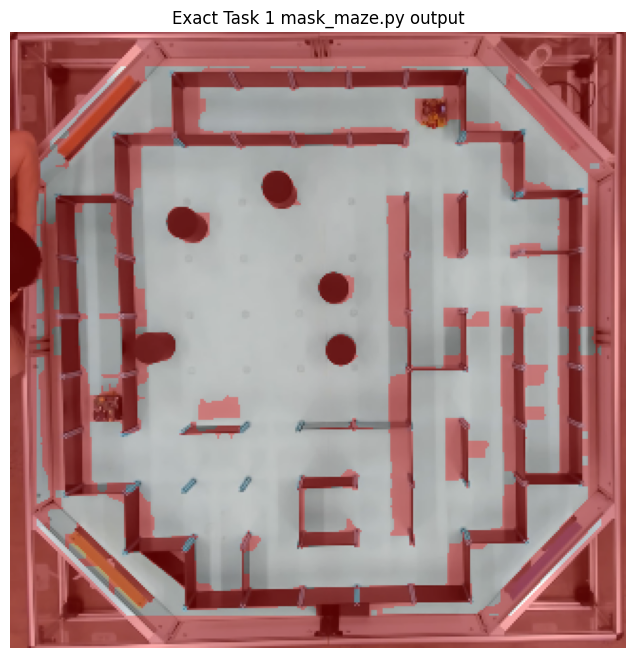

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(result.task1_masks['08_mask_overlay.png'], cv2.COLOR_BGR2RGB))
plt.title('Exact Task 1 mask_maze.py output')
plt.axis('off')
plt.show()

## The two independent maps

Left: the normal 9 x 9 cell graph with the 5 x 5 interior excluded except its two portals. Blue and magenta are the normal routes.

Right: only the 5 x 5 continuous crop. Red is detected cylinders/boundary, amber is robot clearance, and green is the arbitrary-angle A* route.

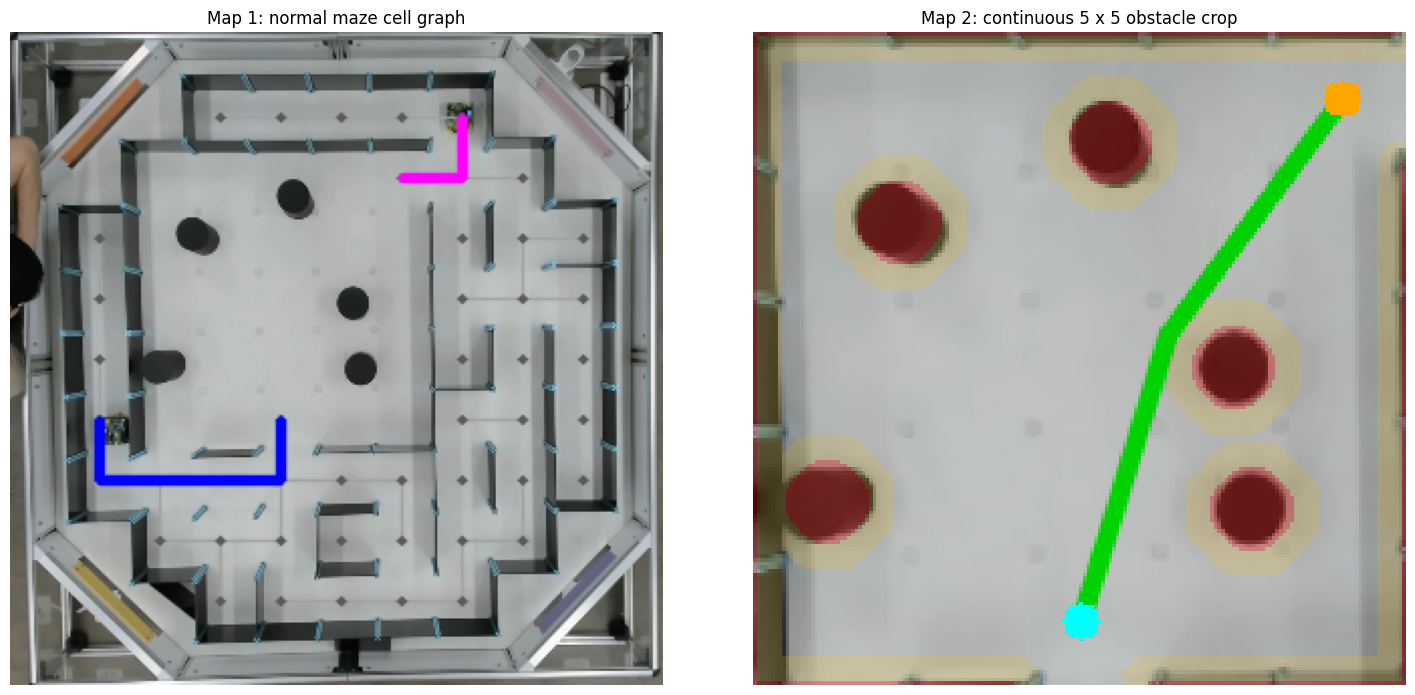

In [ ]:
figure, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(cv2.cvtColor(result.normal_preview_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('Map 1: normal maze cell graph')
axes[1].imshow(cv2.cvtColor(result.obstacle_preview_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title('Map 2: continuous 5 x 5 obstacle crop')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

## Complete joined path on the original camera image

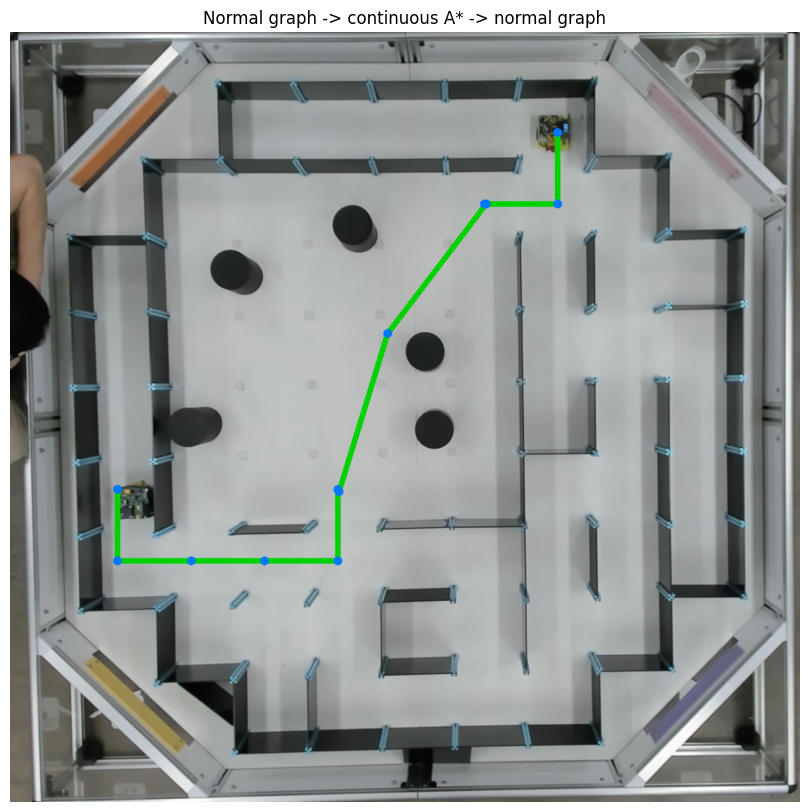

In [ ]:
plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(result.original_preview_bgr, cv2.COLOR_BGR2RGB))
plt.title('Normal graph -> continuous A* -> normal graph')
plt.axis('off')
plt.show()

## Command meaning

The output format is:

```cpp
"normal_lfr,[(obstacle_angle, obstacle_distance_mm), ...],normal_lfr";
```

Outside the brackets, every `f` is exactly one 180 mm cell and turns are 90-degree `l`/`r`. Arbitrary angles occur only inside the brackets. A final zero-distance tuple may align the robot to a cardinal direction before Stage 3.